In [1]:
print("Hello, Fashion AI!")

Hello, Fashion AI!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/products.csv")

In [4]:
df.head()

,product_id,brand,title,price,category,rating,image_url,product_url
0,B08YRWN3WB,JANSPORT,Big Student Large laptop backpack Black EK0A5B...,189.00,New season,4.7,https://m.media-amazon.com/images/I/51y2EF0OmO...,https://www.amazon.ae/dp/B08YRWN3WB
1,B08YRXFZZM,JANSPORT,Superbreak Day Pack,119.00,New season,4.6,https://m.media-amazon.com/images/I/51yvvQUs3S...,https://www.amazon.ae/dp/B08YRXFZZM
2,B09Q2PQ7ZB,BAODINI,Mini Travel Umbrella With Case Small Compact U...,17.79,New season,4.2,https://m.media-amazon.com/images/I/71WbrZPbnG...,https://www.amazon.ae/dp/B09Q2PQ7ZB
3,B001BEAWXY,Calvin Klein,Men's Cotton Classics 3-Pack Boxer Brief,119.00,New season,4.2,https://m.media-amazon.com/images/I/716vzeqa7Z...,https://www.amazon.ae/dp/B001BEAWXY
4,B09FM5PMN3,JANSPORT,Unisex Kids Bag Backpack,179.00,New season,4.4,https://m.media-amazon.com/images/I/51XASBuqjr...,https://www.amazon.ae/dp/B09FM5PMN3


In [5]:
df.shape

(13156, 8)

In [6]:
df.columns

Index(['product_id', 'brand', 'title', 'price', 'category', 'rating',
       'image_url', 'product_url'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13156 entries, 0 to 13155
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   13156 non-null  str    
 1   brand        13155 non-null  str    
 2   title        13155 non-null  str    
 3   price        12963 non-null  float64
 4   category     13156 non-null  str    
 5   rating       12273 non-null  float64
 6   image_url    13156 non-null  str    
 7   product_url  13156 non-null  str    
dtypes: float64(2), str(6)
memory usage: 3.2 MB


Missing values

In [8]:
missing_values = df.isnull().sum()

print(missing_values)

product_id       0
brand            1
title            1
price          193
category         0
rating         883
image_url        0
product_url      0
dtype: int64


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

product_id     0.000000
brand          0.007601
title          0.007601
price          1.467011
category       0.000000
rating         6.711766
image_url      0.000000
product_url    0.000000
dtype: float64


Numerical columns

In [10]:
df[['price', 'rating']].describe()

,price,rating
count,12963.000000,12273.000000
mean,160.915024,4.235191
std,312.435627,0.533392
min,0.990000,1.000000
25%,45.000000,4.000000
50%,93.000000,4.400000
75%,188.000000,4.600000
max,26000.000000,5.000000


In [11]:
df['category'].value_counts()

category
Most-Loved Fashion    1942
Outlet                1434
Made for Amazon       1318
New season            1142
Luggage               1133
Shoes                 1113
Watches               1060
Sportswear            1022
Accessories           1018
Handbags              1013
Wallets                961
Name: count, dtype: int64

In [12]:
df['brand'].nunique()

2408

In [13]:
df['brand'].value_counts().head(10)

brand
Casio             487
adidas            484
Skechers          438
Nike              294
Tommy Hilfiger    271
GUESS             247
Under Armour      214
Generic           207
Centrino          198
PUMA              192
Name: count, dtype: int64

In [14]:
df['price'].describe()

count    12963.000000
mean       160.915024
std        312.435627
min          0.990000
25%         45.000000
50%         93.000000
75%        188.000000
max      26000.000000
Name: price, dtype: float64

In [15]:
df['price'].sort_values(ascending=False).head(10)

11658    26000.00
5809      3187.00
6284      3107.00
5765      2999.00
6486      2825.00
6535      2711.71
11906     2710.61
7662      2593.85
11940     2435.78
11888     2412.00
Name: price, dtype: float64

Data Cleaning

In [16]:
df_clean = df.copy()

print("Original dataset:", df.shape)
print("Working dataset:", df_clean.shape)

Original dataset: (13156, 8)
Working dataset: (13156, 8)


In [17]:
df_clean = df_clean.dropna(subset=['brand', 'title'])

In [18]:
print(df_clean.shape)

(13155, 8)


Price distribution

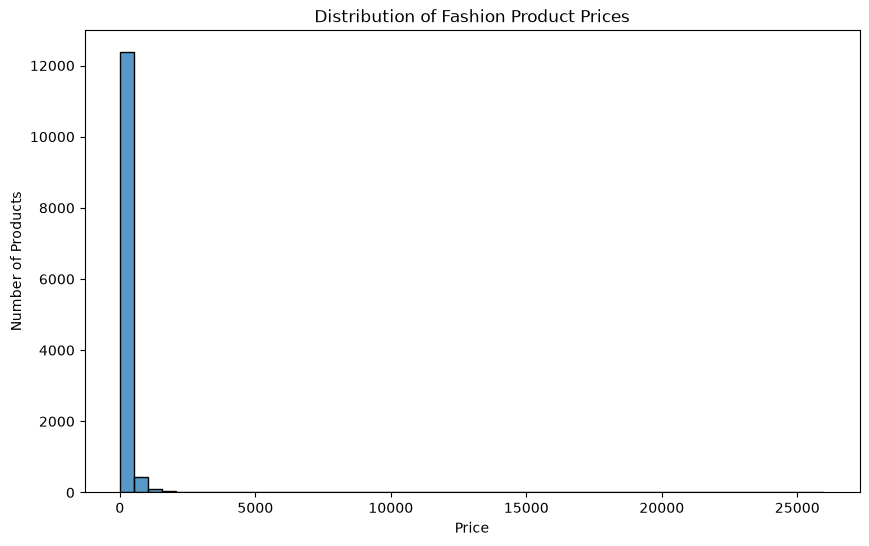

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(df_clean['price'].dropna(), bins=50)

plt.title('Distribution of Fashion Product Prices')
plt.xlabel('Price')
plt.ylabel('Number of Products')

plt.show()

In [20]:
df_clean['price'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     345.18000
0.950     499.99000
0.990    1120.91910
0.995    1474.24340
0.999    2185.59163
Name: price, dtype: float64

Duplicated products

In [21]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 667


In [22]:
print("Duplicate product IDs:", df_clean['product_id'].duplicated().sum())

Duplicate product IDs: 1787


In [23]:
duplicate_rows = df_clean[df_clean.duplicated(keep=False)]

print("Total rows involved in exact duplicates:", len(duplicate_rows))

Total rows involved in exact duplicates: 1263


In [24]:
duplicate_rows.head(10)

,product_id,brand,title,price,category,rating,image_url,product_url
143,B0C4PJ3R1M,Nike,Nike Court Borough Low Recraft unisex-child Sn...,289.80,New season,4.5,https://m.media-amazon.com/images/I/710wWRkdZ8...,https://www.amazon.ae/dp/B0C4PJ3R1M
144,B0C4PJ3R1M,Nike,Nike Court Borough Low Recraft unisex-child Sn...,289.80,New season,4.5,https://m.media-amazon.com/images/I/710wWRkdZ8...,https://www.amazon.ae/dp/B0C4PJ3R1M
383,B0DP2X1JDB,Brooks,Glycerin Max mens Sneaker,705.00,New season,4.5,https://m.media-amazon.com/images/I/71-gHDhNQ+...,https://www.amazon.ae/dp/B0DP2X1JDB
384,B0DP2X1JDB,Brooks,Glycerin Max mens Sneaker,705.00,New season,4.5,https://m.media-amazon.com/images/I/71-gHDhNQ+...,https://www.amazon.ae/dp/B0DP2X1JDB
575,B01NBABBKU,Urban Classics,Women's Ladies Light Bomber Jacket Urban Class...,102.13,New season,4.3,https://m.media-amazon.com/images/I/61E791Ud2I...,https://www.amazon.ae/dp/B01NBABBKU
576,B01NBABBKU,Urban Classics,Women's Ladies Light Bomber Jacket Urban Class...,102.13,New season,4.3,https://m.media-amazon.com/images/I/61E791Ud2I...,https://www.amazon.ae/dp/B01NBABBKU
621,B06XWHNN53,Silver Jeans Co.,mens Craig Easy Fit Bootcut Jean Jeans,152.80,New season,4.5,https://m.media-amazon.com/images/I/811PIRTFCj...,https://www.amazon.ae/dp/B06XWHNN53
622,B01K0ETOAC,Legendary Whitetails,Men's Buck Camp Flannel Shirt Button Down Shirt,46.34,New season,4.6,https://m.media-amazon.com/images/I/71JBbYy3WM...,https://www.amazon.ae/dp/B01K0ETOAC
623,B000A2KCAG,Wrangler,Men's Ranger Pant Ranger Pant,128.00,New season,4.3,https://m.media-amazon.com/images/I/619ZoUpzwl...,https://www.amazon.ae/dp/B000A2KCAG
624,B06XWHNN53,Silver Jeans Co.,mens Craig Easy Fit Bootcut Jean Jeans,152.80,New season,4.5,https://m.media-amazon.com/images/I/811PIRTFCj...,https://www.amazon.ae/dp/B06XWHNN53


In [25]:
duplicate_ids = df_clean[df_clean['product_id'].duplicated(keep=False)]

print("Rows with duplicated product IDs:", len(duplicate_ids))

Rows with duplicated product IDs: 3400


In [26]:
duplicate_ids.sort_values('product_id').head(20)

,product_id,brand,title,price,category,rating,image_url,product_url
2465,B00075U5I0,Invicta,Men's 0073 Pro Diver Collection Chronograph 18...,173.94,Most-Loved Fashion,4.6,https://m.media-amazon.com/images/I/612jtwvsK6...,https://www.amazon.ae/dp/B00075U5I
11785,B00075U5I0,Invicta,Men's 0073 Pro Diver Collection Chronograph 18...,173.94,Watches,4.6,https://m.media-amazon.com/images/I/612jtwvsK6...,https://www.amazon.ae/dp/B00075U5I
11221,B0007L8A18,Casio,Casual Watch Digital Display Quartz For Men,85.00,Watches,4.3,https://m.media-amazon.com/images/I/51q6cfJa9E...,https://www.amazon.ae/dp/B0007L8A18
11222,B0007L8A18,Casio,Casual Watch Digital Display Quartz For Men,85.00,Watches,4.3,https://m.media-amazon.com/images/I/51q6cfJa9E...,https://www.amazon.ae/dp/B0007L8A18
1689,B0007QCQGI,JanSport,Superbreak Backpack,208.29,Most-Loved Fashion,4.6,https://m.media-amazon.com/images/I/81g+yVaD0T...,https://www.amazon.ae/dp/B0007QCQGI
5771,B0007QCQGI,JanSport,Superbreak Backpack,208.29,Luggage,4.6,https://m.media-amazon.com/images/I/81g+yVaD0T...,https://www.amazon.ae/dp/B0007QCQGI
2228,B0007TQ9PY,Dockers,Gordon Men’s Leather Oxford Dress Shoe,116.69,Most-Loved Fashion,4.4,https://m.media-amazon.com/images/I/51bt2lf5Pp...,https://www.amazon.ae/dp/B0007TQ9PY
9650,B0007TQ9PY,Dockers,Gordon Men’s Leather Oxford Dress Shoe,116.69,Shoes,4.4,https://m.media-amazon.com/images/I/51bt2lf5Pp...,https://www.amazon.ae/dp/B0007TQ9PY
623,B000A2KCAG,Wrangler,Men's Ranger Pant Ranger Pant,128.00,New season,4.3,https://m.media-amazon.com/images/I/619ZoUpzwl...,https://www.amazon.ae/dp/B000A2KCAG
626,B000A2KCAG,Wrangler,Men's Ranger Pant Ranger Pant,128.00,New season,4.3,https://m.media-amazon.com/images/I/619ZoUpzwl...,https://www.amazon.ae/dp/B000A2KCAG


In [27]:
id_counts = df_clean['product_id'].value_counts()

print(id_counts.value_counts().sort_index())

count
1    9755
2    1461
3     132
4      18
5       2
Name: count, dtype: int64


In [28]:
duplicate_id = id_counts[id_counts > 1].index[0]

df_clean[df_clean['product_id'] == duplicate_id]

,product_id,brand,title,price,category,rating,image_url,product_url
983,B0D7D7G5YP,Calvin Klein,Minimal Monogram Ew Camera Bag Handbags For Wo...,170.85,New season,5.0,https://m.media-amazon.com/images/I/71cLap7ZkE...,https://www.amazon.ae/dp/B0D7D7G5YP
4434,B0D7D7G5YP,Calvin Klein,Minimal Monogram Ew Camera Bag Handbags For Wo...,170.85,Handbags,5.0,https://m.media-amazon.com/images/I/71cLap7ZkE...,https://www.amazon.ae/dp/B0D7D7G5YP
4679,B0D7D7G5YP,Calvin Klein,Minimal Monogram Ew Camera Bag Handbags For Wo...,170.85,Handbags,5.0,https://m.media-amazon.com/images/I/71cLap7ZkE...,https://www.amazon.ae/dp/B0D7D7G5YP
4771,B0D7D7G5YP,Calvin Klein,Minimal Monogram Ew Camera Bag Handbags For Wo...,170.85,Handbags,5.0,https://m.media-amazon.com/images/I/71cLap7ZkE...,https://www.amazon.ae/dp/B0D7D7G5YP
4809,B0D7D7G5YP,Calvin Klein,Minimal Monogram Ew Camera Bag Handbags For Wo...,170.85,Handbags,5.0,https://m.media-amazon.com/images/I/71cLap7ZkE...,https://www.amazon.ae/dp/B0D7D7G5YP


In [29]:
df_clean.nlargest(20, 'price')[[
    'product_id',
    'brand',
    'title',
    'price',
    'category',
    'rating'
]]

,product_id,brand,title,price,category,rating
11658,B07RDWW4Y1,Hublot,Classic Fusion Automatic Men's Watch,26000.00,Watches,NaN
5809,B07MX2GMZM,TUMI,Unisex Alpha 3 Continental Expandable 4 Wheele...,3187.00,Luggage,4.1
6284,B07MQWFCHC,TUMI,Alpha 2 International Front Lid 4 Wheeled Carr...,3107.00,Luggage,3.9
5765,B0CF9M1MKL,Airwheel,SE3S Electric Scooter Suitcase - Pink | 20L In...,2999.00,Luggage,5.0
6486,B097ZY43HQ,TUMI,Unisex Adult 19 Degree Luggage- Carry-On Luggage,2825.00,Luggage,4.4
6535,B0BLQHNLTJ,Samsonite,C-Lite Expandable Spinner Suitcase,2711.71,Luggage,4.6
11906,B07R8MDDM4,Victorinox,Victorinox I.N.O.X. Carbon Quartz Watch Carbon,2710.61,Watches,3.8
7662,B0BVD8RCYR,Bulova,Men's Archive Series MIL-SHIPS-W-2181 Stainles...,2593.85,Outlet,4.4
11940,B07DHBMKD6,Tissot,TISSOT watch Sea Star 1000 Automatic T12040711...,2435.78,Watches,4.5
11888,B0BP7R3FMF,Seiko,Men's Presage Blue Dial Automatic Anaog Watch ...,2412.00,Watches,4.0


In [30]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicate rows removed:", before - after)

Rows before removing duplicates: 13155
Rows after removing duplicates: 12488
Duplicate rows removed: 667


In [31]:
print("Rows:", len(df_clean))
print("Unique products:", df_clean['product_id'].nunique())
print("Remaining duplicated product IDs:",
      df_clean['product_id'].duplicated().sum())

Rows: 12488
Unique products: 11368
Remaining duplicated product IDs: 1120


In [32]:
product_group_sizes = (
    df_clean
    .groupby('product_id')
    .size()
    .sort_values(ascending=False)
)

print(product_group_sizes.head(20))

product_id
B076CW51NS    3
B07DGPQVTC    3
B09HZFXMPT    3
B07S84MY51    3
B07PVBT5G7    3
B07N88X8RF    3
B08LMSPP2X    3
B078141ML8    3
B093QMCXMM    3
B0874W4WR5    3
B08YRWN3WB    3
B077G9SV4V    3
B07RDQP247    3
B07H4RM9LJ    3
B07ZQFLRY6    3
B07FKFHTF7    3
B07S6NT8GF    3
B0785FWNL6    3
B08YRXFZZM    3
B0066T2HS2    3
dtype: int64


In [33]:
most_repeated_id = product_group_sizes.index[0]

df_clean[df_clean['product_id'] == most_repeated_id][[
    'product_id',
    'brand',
    'title',
    'price',
    'category',
    'rating'
]]

,product_id,brand,title,price,category,rating
2220,B076CW51NS,Stacy Adams,DESMOND CAP TOE MONK STRAP Men's Monk-Strap Lo...,279.0,Most-Loved Fashion,4.2
6615,B076CW51NS,Stacy Adams,DESMOND CAP TOE MONK STRAP Men's Monk-Strap Lo...,279.0,Outlet,4.2
10066,B076CW51NS,Stacy Adams,DESMOND CAP TOE MONK STRAP Men's Monk-Strap Lo...,279.0,Shoes,4.2


In [34]:
df_clean.nlargest(20, 'price')[[
    'product_id',
    'brand',
    'title',
    'price',
    'category',
    'rating'
]]

,product_id,brand,title,price,category,rating
11658,B07RDWW4Y1,Hublot,Classic Fusion Automatic Men's Watch,26000.00,Watches,NaN
5809,B07MX2GMZM,TUMI,Unisex Alpha 3 Continental Expandable 4 Wheele...,3187.00,Luggage,4.1
6284,B07MQWFCHC,TUMI,Alpha 2 International Front Lid 4 Wheeled Carr...,3107.00,Luggage,3.9
5765,B0CF9M1MKL,Airwheel,SE3S Electric Scooter Suitcase - Pink | 20L In...,2999.00,Luggage,5.0
6486,B097ZY43HQ,TUMI,Unisex Adult 19 Degree Luggage- Carry-On Luggage,2825.00,Luggage,4.4
6535,B0BLQHNLTJ,Samsonite,C-Lite Expandable Spinner Suitcase,2711.71,Luggage,4.6
11906,B07R8MDDM4,Victorinox,Victorinox I.N.O.X. Carbon Quartz Watch Carbon,2710.61,Watches,3.8
7662,B0BVD8RCYR,Bulova,Men's Archive Series MIL-SHIPS-W-2181 Stainles...,2593.85,Outlet,4.4
11940,B07DHBMKD6,Tissot,TISSOT watch Sea Star 1000 Automatic T12040711...,2435.78,Watches,4.5
11888,B0BP7R3FMF,Seiko,Men's Presage Blue Dial Automatic Anaog Watch ...,2412.00,Watches,4.0


In [35]:
print("Unique ratings:")
print(sorted(df_clean['rating'].dropna().unique()))

Unique ratings:
[np.float64(1.0), np.float64(1.5), np.float64(1.6), np.float64(1.7), np.float64(1.8), np.float64(1.9), np.float64(2.0), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(2.9), np.float64(3.0), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9), np.float64(5.0)]


In [36]:
df_products = df_clean.drop_duplicates(subset='product_id').copy()

print("Product-level dataset:", df_products.shape)
print("Unique product IDs:", df_products['product_id'].nunique())

Product-level dataset: (11368, 8)
Unique product IDs: 11368


In [37]:
print(df_clean['category'].value_counts())

category
Most-Loved Fashion    1934
Outlet                1434
Made for Amazon       1317
New season            1121
Luggage               1121
Shoes                 1093
Watches               1054
Sportswear            1009
Wallets                957
Accessories            749
Handbags               699
Name: count, dtype: int64


In [38]:
print("Number of categories:", df_clean['category'].nunique())

Number of categories: 11


In [39]:
df_products.nlargest(20, 'price')[[
    'brand',
    'title',
    'price',
    'category',
    'rating'
]]

,brand,title,price,category,rating
11658,Hublot,Classic Fusion Automatic Men's Watch,26000.00,Watches,NaN
5809,TUMI,Unisex Alpha 3 Continental Expandable 4 Wheele...,3187.00,Luggage,4.1
6284,TUMI,Alpha 2 International Front Lid 4 Wheeled Carr...,3107.00,Luggage,3.9
5765,Airwheel,SE3S Electric Scooter Suitcase - Pink | 20L In...,2999.00,Luggage,5.0
6486,TUMI,Unisex Adult 19 Degree Luggage- Carry-On Luggage,2825.00,Luggage,4.4
6535,Samsonite,C-Lite Expandable Spinner Suitcase,2711.71,Luggage,4.6
11906,Victorinox,Victorinox I.N.O.X. Carbon Quartz Watch Carbon,2710.61,Watches,3.8
7662,Bulova,Men's Archive Series MIL-SHIPS-W-2181 Stainles...,2593.85,Outlet,4.4
11940,Tissot,TISSOT watch Sea Star 1000 Automatic T12040711...,2435.78,Watches,4.5
11888,Seiko,Men's Presage Blue Dial Automatic Anaog Watch ...,2412.00,Watches,4.0


In [40]:
df_products = df_clean.drop_duplicates(subset='product_id').copy()

print("Product-level dataset:", df_products.shape)
print("Unique product IDs:", df_products['product_id'].nunique())

Product-level dataset: (11368, 8)
Unique product IDs: 11368


In [41]:
print(df_clean['category'].value_counts())
print("Number of categories:", df_clean['category'].nunique())

category
Most-Loved Fashion    1934
Outlet                1434
Made for Amazon       1317
New season            1121
Luggage               1121
Shoes                 1093
Watches               1054
Sportswear            1009
Wallets                957
Accessories            749
Handbags               699
Name: count, dtype: int64
Number of categories: 11


Which fashion categories have the most products?

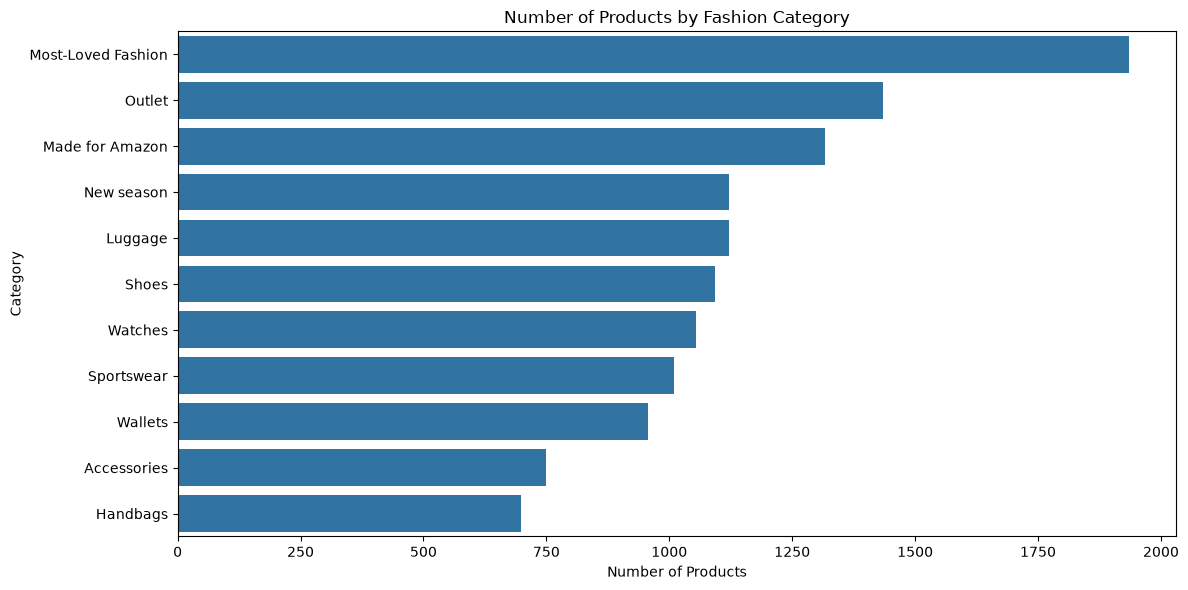

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = df_clean['category'].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title('Number of Products by Fashion Category')
plt.xlabel('Number of Products')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

Why is the mean price ($160.92) so much higher than the median ($93)?

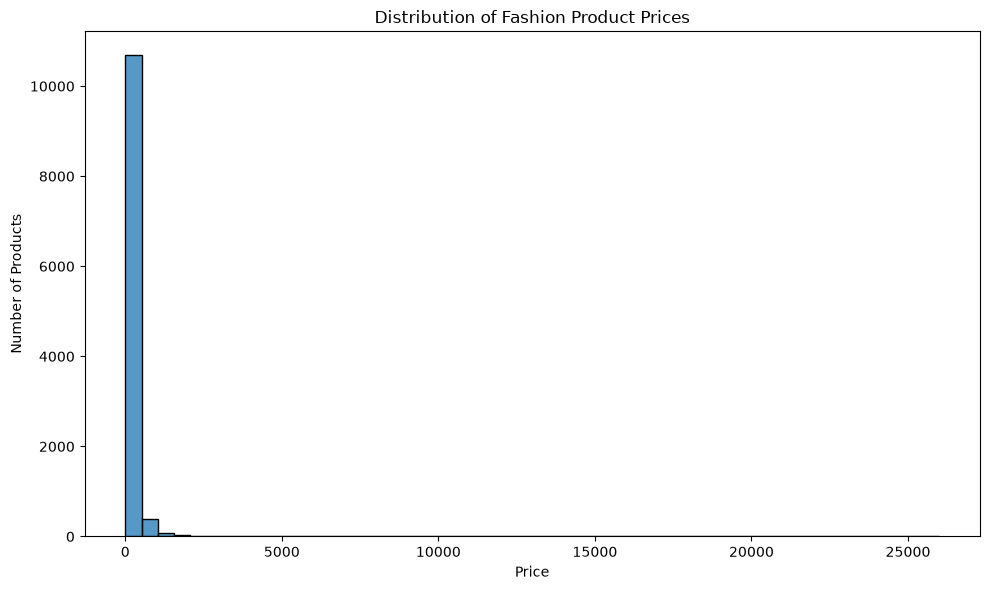

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_products['price'].dropna(),
    bins=50
)

plt.title('Distribution of Fashion Product Prices')
plt.xlabel('Price')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

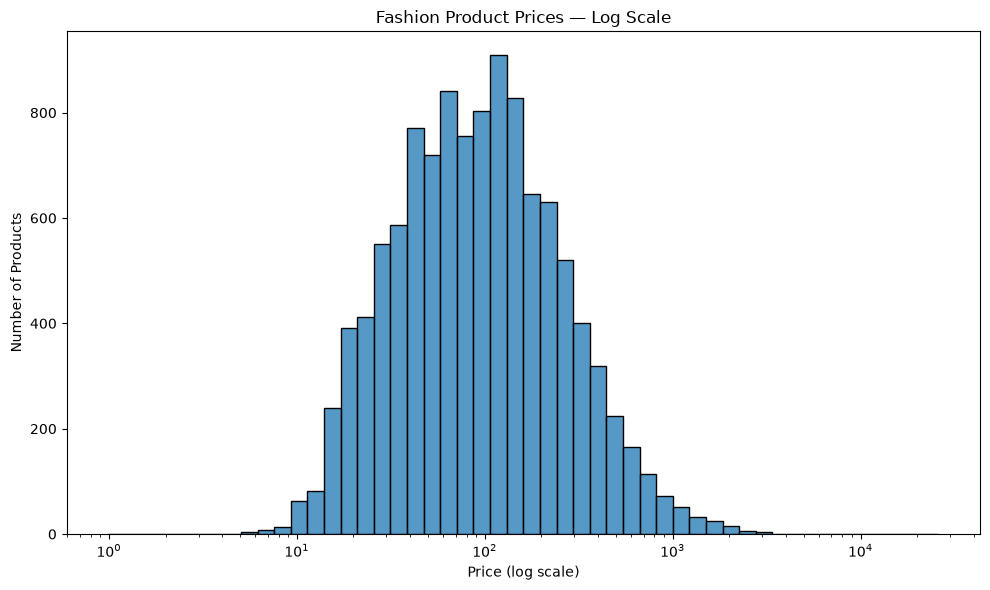

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_products['price'].dropna(),
    bins=50,
    log_scale=True
)

plt.title('Fashion Product Prices — Log Scale')
plt.xlabel('Price (log scale)')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

Customer Ratings

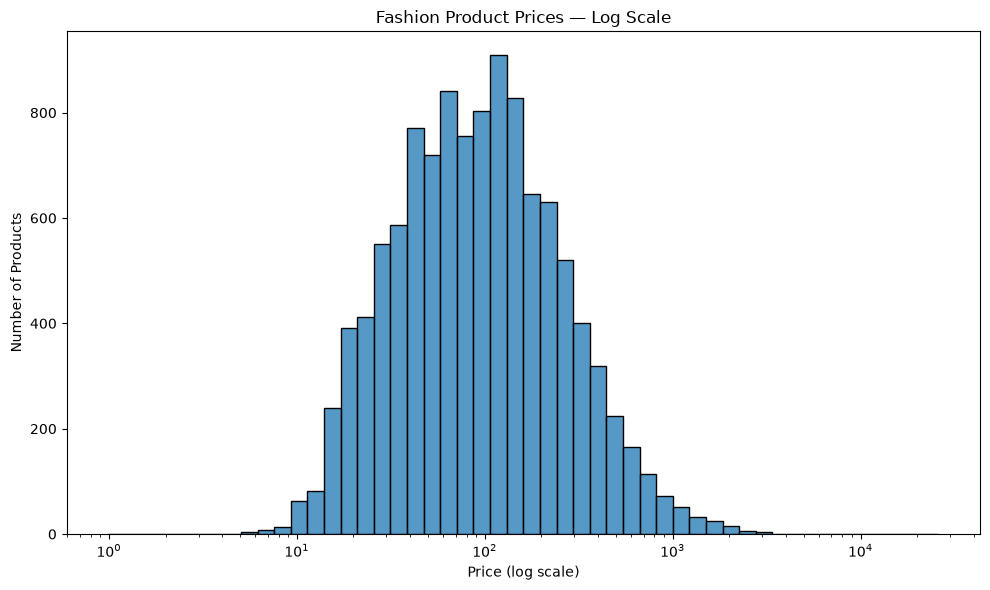

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_products['price'].dropna(),
    bins=50,
    log_scale=True
)

plt.title('Fashion Product Prices — Log Scale')
plt.xlabel('Price (log scale)')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

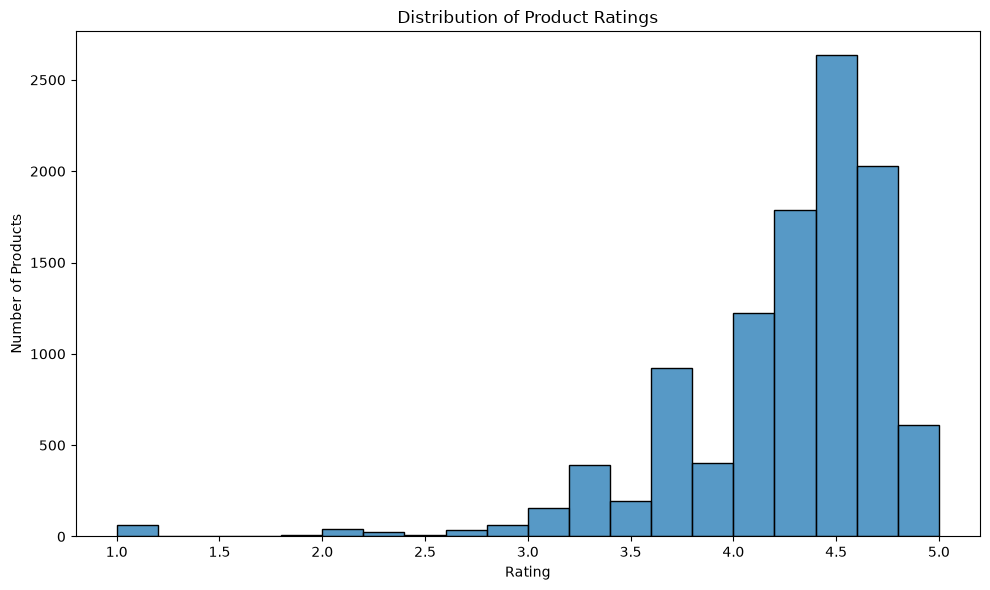

In [46]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_products['rating'].dropna(),
    bins=20
)

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

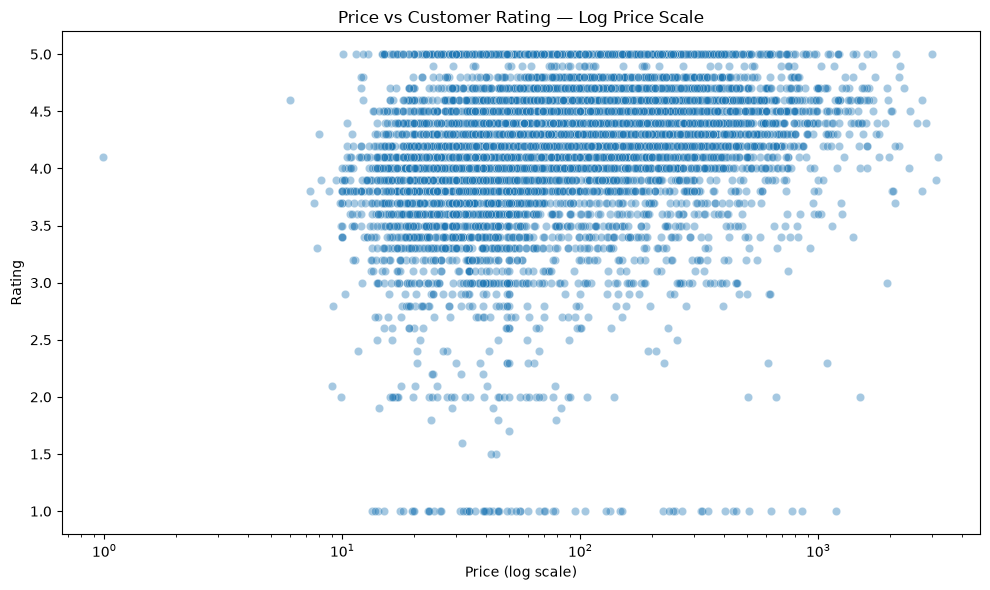

In [47]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_products,
    x='price',
    y='rating',
    alpha=0.4
)

plt.xscale('log')

plt.title('Price vs Customer Rating — Log Price Scale')
plt.xlabel('Price (log scale)')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

Create the analysis data

In [48]:
correlation_data = df_products[['price', 'rating']].dropna()

print("Products used for correlation analysis:", len(correlation_data))

Products used for correlation analysis: 10438


Calculate Pearson correlation

In [49]:
correlation = correlation_data['price'].corr(
    correlation_data['rating']
)

print("Price-Rating correlation:", round(correlation, 3))

Price-Rating correlation: 0.154


Correlation using log price

In [50]:
import numpy as np

correlation_data = correlation_data.copy()

correlation_data['log_price'] = np.log1p(
    correlation_data['price']
)

log_correlation = correlation_data['log_price'].corr(
    correlation_data['rating']
)

print("Log Price-Rating correlation:", round(log_correlation, 3))

Log Price-Rating correlation: 0.305


Average price by category

In [51]:
category_price = (
    df_clean.groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

print(category_price.round(2))

category
Watches               353.29
Handbags              222.11
Outlet                208.56
Shoes                 189.60
Luggage               183.28
New season            151.85
Most-Loved Fashion    144.76
Wallets               116.99
Accessories            92.47
Sportswear             85.03
Made for Amazon        33.88
Name: price, dtype: float64


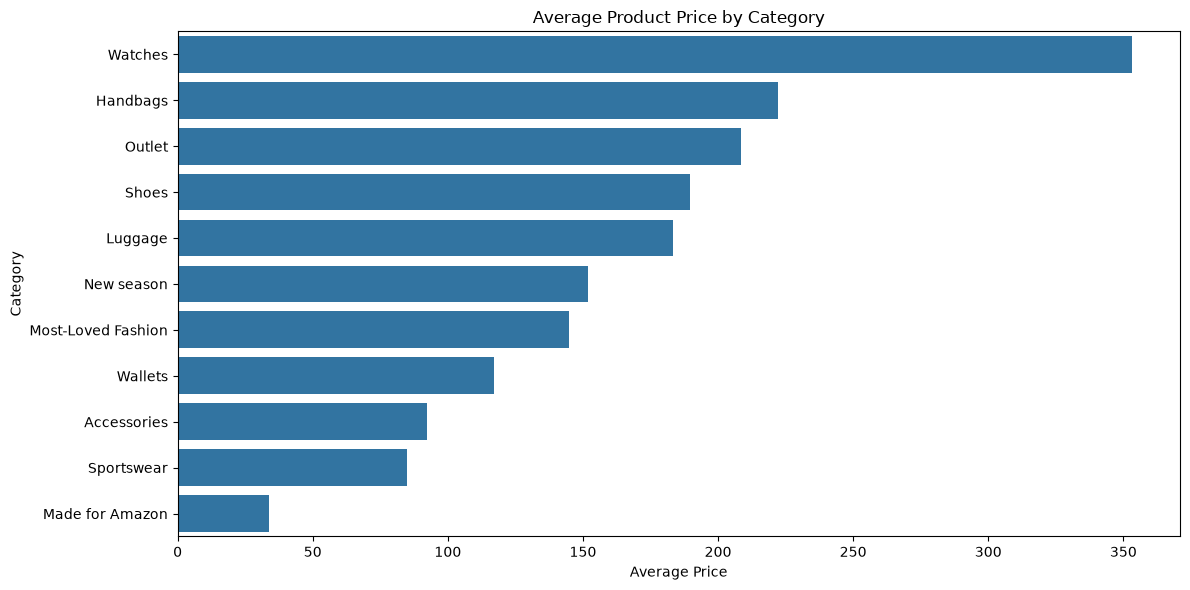

In [52]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_price.values,
    y=category_price.index
)

plt.title('Average Product Price by Category')
plt.xlabel('Average Price')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

Average rating by category

In [53]:
category_rating = (
    df_clean.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
)

print(category_rating.round(2))

category
Most-Loved Fashion    4.42
New season            4.39
Luggage               4.38
Watches               4.31
Sportswear            4.28
Wallets               4.25
Accessories           4.23
Shoes                 4.22
Handbags              4.22
Outlet                4.19
Made for Amazon       3.66
Name: rating, dtype: float64


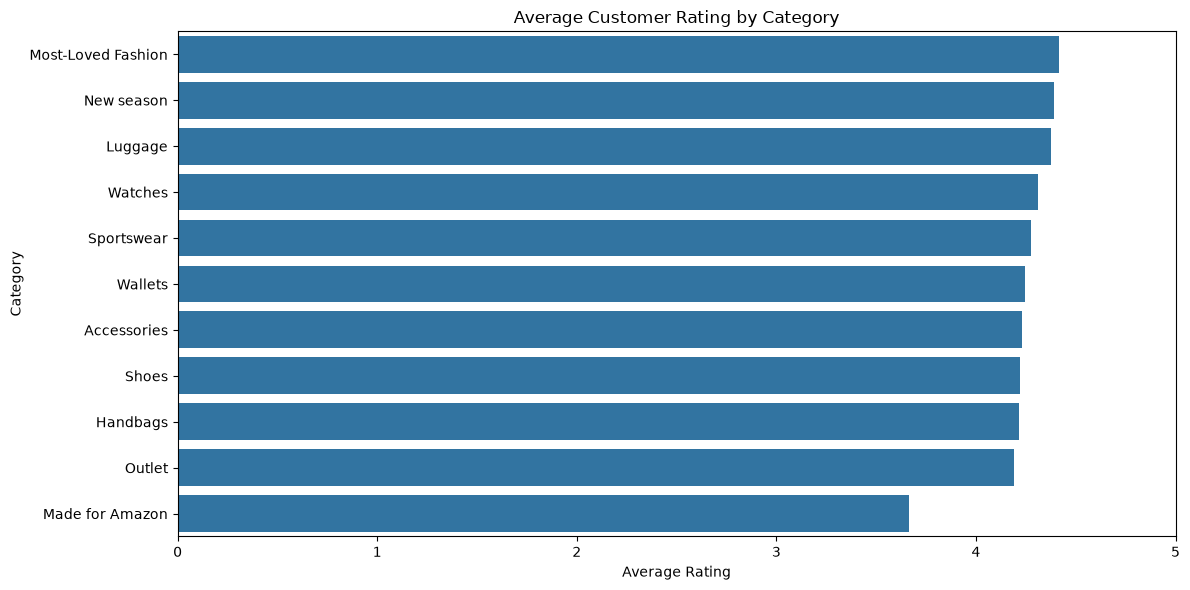

In [54]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_rating.values,
    y=category_rating.index
)

plt.title('Average Customer Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

Top 15 brands by number of products.

In [55]:
top_brands = df_products['brand'].value_counts().head(15)

print(top_brands)

brand
Casio             409
adidas            390
Skechers          367
Nike              228
Tommy Hilfiger    220
Generic           186
Centrino          182
GUESS             179
PUMA              162
Under Armour      159
styleville.in     138
Crocs             119
YELLOW CHIMES     117
Calvin Klein      116
JACK & JONES      115
Name: count, dtype: int64


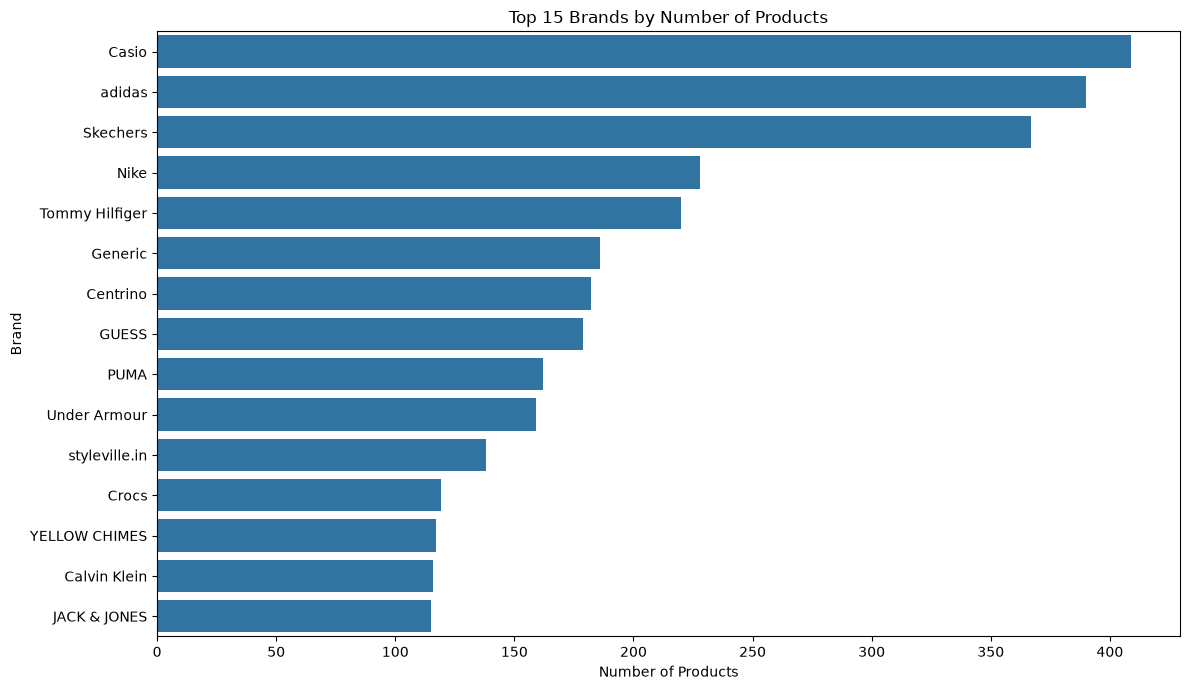

In [56]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title('Top 15 Brands by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Brand')

plt.tight_layout()
plt.show()

Brand price analysis

In [57]:
brand_price = (
    df_products.groupby('brand')['price']
    .agg(['count', 'mean', 'median'])
    .sort_values('count', ascending=False)
)

print(brand_price.head(15).round(2))

                count    mean  median
brand                                
Casio             404  205.39  134.55
adidas            388  125.42  107.28
Skechers          359  174.34  161.62
Nike              216  158.22  121.50
Tommy Hilfiger    210  235.98  209.00
Generic           186   51.09   35.00
Centrino          182   34.83   34.00
GUESS             178  312.74  286.84
PUMA              159  122.53  109.00
Under Armour      150  134.57  119.00
styleville.in     138   31.90   30.14
Crocs             117  136.19  126.94
YELLOW CHIMES     117   26.66   21.04
Fusefit           115   34.07   29.00
JACK & JONES      112   92.35   79.70


Brand rating analysis

In [58]:
brand_rating = (
    df_products.groupby('brand')['rating']
    .agg(['count', 'mean', 'median'])
    .sort_values('count', ascending=False)
)

print(brand_rating.head(15).round(2))

                count  mean  median
brand                              
Casio             397  4.42     4.4
adidas            374  4.34     4.4
Skechers          357  4.42     4.4
Nike              212  4.37     4.5
Tommy Hilfiger    210  4.33     4.4
Centrino          181  3.52     3.6
GUESS             159  4.43     4.5
Under Armour      155  4.47     4.5
PUMA              154  4.41     4.4
styleville.in     123  3.69     3.8
Crocs             119  4.51     4.5
YELLOW CHIMES     117  3.92     3.9
Fusefit           114  3.63     3.7
JACK & JONES      110  4.25     4.3
Calvin Klein      109  4.39     4.4


Best-rated brands with enough products

In [59]:
brand_performance = (
    df_products.groupby('brand')
    .agg(
        product_count=('product_id', 'count'),
        rated_products=('rating', 'count'),
        average_price=('price', 'mean'),
        median_price=('price', 'median'),
        average_rating=('rating', 'mean')
    )
)

reliable_brands = (
    brand_performance[
        brand_performance['rated_products'] >= 20
    ]
    .sort_values('average_rating', ascending=False)
)

print(reliable_brands.head(15).round(2))

                     product_count  rated_products  average_price  \
brand                                                               
JANSPORT                        63              50         184.10   
Orient                          21              20         820.90   
Kipling                         43              43         295.83   
CRZ YOGA                        20              20          97.87   
Vans                            23              23         128.94   
Oakley                          26              24         313.08   
ah arctic hunter                32              32         124.97   
Crocs                          119             119         136.19   
Herschel                        48              46         133.26   
Nautica                         24              24         140.21   
Columbia                        59              59         177.59   
Havaianas                       32              32          87.82   
PANDORA                         24

Brand Performance Map

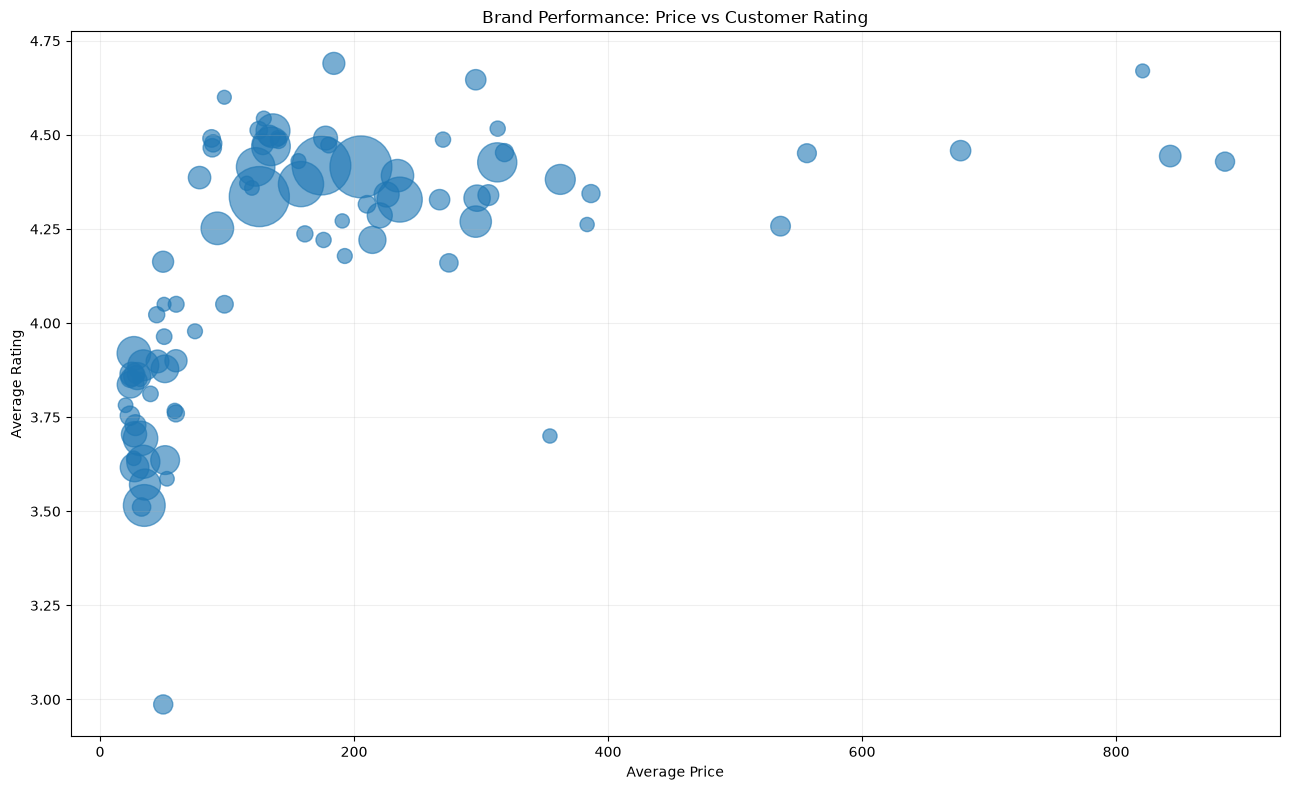

In [60]:
# Select brands with at least 20 rated products
brand_plot = reliable_brands.copy()

plt.figure(figsize=(13, 8))

plt.scatter(
    brand_plot['average_price'],
    brand_plot['average_rating'],
    s=brand_plot['rated_products'] * 5,
    alpha=0.6
)

plt.xlabel('Average Price')
plt.ylabel('Average Rating')
plt.title('Brand Performance: Price vs Customer Rating')

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Better version with log price

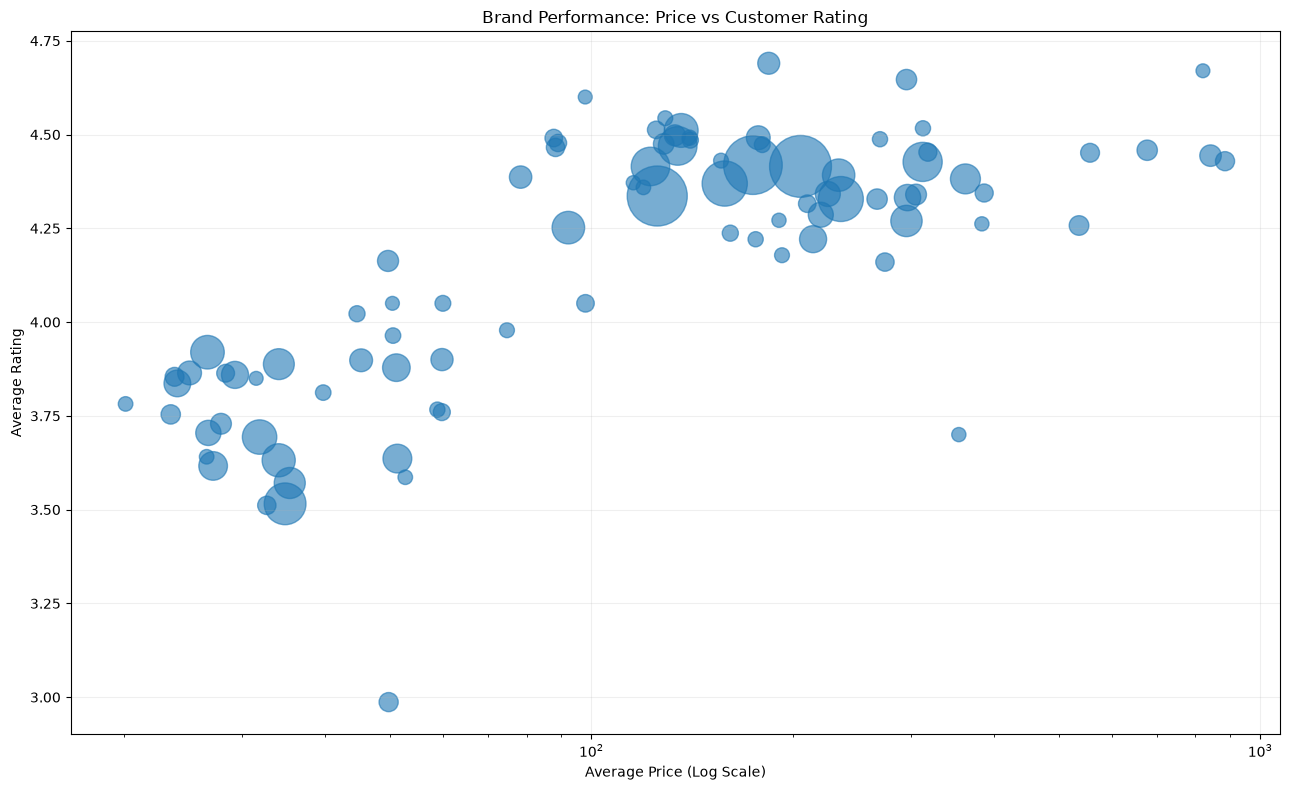

In [61]:
plt.figure(figsize=(13, 8))

plt.scatter(
    brand_plot['average_price'],
    brand_plot['average_rating'],
    s=brand_plot['rated_products'] * 5,
    alpha=0.6
)

plt.xscale('log')

plt.xlabel('Average Price (Log Scale)')
plt.ylabel('Average Rating')
plt.title('Brand Performance: Price vs Customer Rating')

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [62]:
brand_summary = reliable_brands[
    [
        'product_count',
        'rated_products',
        'average_price',
        'median_price',
        'average_rating'
    ]
].copy()

brand_summary = brand_summary.sort_values(
    'average_rating',
    ascending=False
)

print(brand_summary.head(20).round(2))

                     product_count  rated_products  average_price  \
brand                                                               
JANSPORT                        63              50         184.10   
Orient                          21              20         820.90   
Kipling                         43              43         295.83   
CRZ YOGA                        20              20          97.87   
Vans                            23              23         128.94   
Oakley                          26              24         313.08   
ah arctic hunter                32              32         124.97   
Crocs                          119             119         136.19   
Herschel                        48              46         133.26   
Nautica                         24              24         140.21   
Columbia                        59              59         177.59   
Havaianas                       32              32          87.82   
PANDORA                         24

Investigate the category structure

In [63]:
category_counts_per_product = (
    df_clean.groupby('product_id')['category']
    .nunique()
)

print("Products with 1 category:",
      (category_counts_per_product == 1).sum())

print("Products with 2 categories:",
      (category_counts_per_product == 2).sum())

print("Products with 3+ categories:",
      (category_counts_per_product >= 3).sum())

print("Maximum categories for one product:",
      category_counts_per_product.max())

Products with 1 category: 10319
Products with 2 categories: 981
Products with 3+ categories: 68
Maximum categories for one product: 3


In [64]:
print(
    category_counts_per_product.value_counts()
    .sort_index()
)

category
1    10319
2      981
3       68
Name: count, dtype: int64


New DataFrame containing only products with exactly one category

In [65]:
# Count how many categories each product has
category_counts = (
    df_clean.groupby('product_id')['category']
    .nunique()
)

# Keep only products with exactly one category
single_category_ids = category_counts[
    category_counts == 1
].index

ml_data = df_products[
    df_products['product_id'].isin(single_category_ids)
].copy()

print("ML dataset shape:", ml_data.shape)
print("Unique products:", ml_data['product_id'].nunique())
print("Categories:", ml_data['category'].nunique())

print("\nCategory distribution:")
print(ml_data['category'].value_counts())

ML dataset shape: (10319, 8)
Unique products: 10319
Categories: 11

Category distribution:
category
Outlet                1319
Most-Loved Fashion    1296
Made for Amazon       1258
Luggage                932
Watches                895
Wallets                885
Sportswear             857
Shoes                  791
New season             725
Accessories            717
Handbags               644
Name: count, dtype: int64


In [66]:
category_check = (
    df_clean[
        df_clean['product_id'].isin(single_category_ids)
    ]
    .groupby('product_id')['category']
    .nunique()
)

print(category_check.value_counts())

category
1    10319
Name: count, dtype: int64


Check the ML dataset

In [67]:
print(ml_data.shape)
print(ml_data[['brand', 'title', 'price', 'category']].head())

(10319, 8)
           brand                                              title   price  \
2        BAODINI  Mini Travel Umbrella With Case Small Compact U...   17.79   
3   Calvin Klein           Men's Cotton Classics 3-Pack Boxer Brief  119.00   
6           yeuG  Non Slip Pilates Socks with Grips for Women, G...   19.00   
9       JANSPORT           Unisex Basic Accessory Pouch Pencil case     NaN   
12       livbote  Gym Bag for Women Men with Shoe Compartment, S...   37.90   

      category  
2   New season  
3   New season  
6   New season  
9   New season  
12  New season  


Check the classes

In [68]:
class_counts = ml_data['category'].value_counts()

print(class_counts)

category
Outlet                1319
Most-Loved Fashion    1296
Made for Amazon       1258
Luggage                932
Watches                895
Wallets                885
Sportswear             857
Shoes                  791
New season             725
Accessories            717
Handbags               644
Name: count, dtype: int64


In [69]:
print("\nSmallest category:", class_counts.min())
print("Largest category:", class_counts.max())


Smallest category: 644
Largest category: 1319


Train/Test Split

In [70]:
from sklearn.model_selection import train_test_split

X = ml_data[['title', 'brand', 'price']]
y = ml_data['category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8255
Testing samples: 2064


TF-IDF + Logistic Regression

Import the ML tools

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Make copies so we don't accidentally change the original data
X_train = X_train.copy()
X_test = X_test.copy()

# Fill missing values
X_train['title'] = X_train['title'].fillna('')
X_test['title'] = X_test['title'].fillna('')

X_train['brand'] = X_train['brand'].fillna('Unknown')
X_test['brand'] = X_test['brand'].fillna('Unknown')

# Use the training-set median price
price_median = X_train['price'].median()

X_train['price'] = X_train['price'].fillna(price_median)
X_test['price'] = X_test['price'].fillna(price_median)

print("Missing values after cleaning:")
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Missing values after cleaning:
title    0
brand    0
price    0
dtype: int64
title    0
brand    0
price    0
dtype: int64


Preprocessor

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            'title',
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                stop_words='english'
            ),
            'title'
        ),
        (
            'brand',
            OneHotEncoder(handle_unknown='ignore'),
            ['brand']
        ),
        (
            'price',
            StandardScaler(),
            ['price']
        )
    ]
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced'
            )
        )
    ]
)

print("Model pipeline created successfully!")

Model pipeline created successfully!


Train the model

In [73]:
print("Training Fashion Category Classifier...")

model.fit(X_train, y_train)

print("Training completed!")

Training Fashion Category Classifier...
Training completed!


In [74]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

# Show detailed performance for each category
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 78.59%

Classification Report:
                    precision    recall  f1-score   support

       Accessories       0.94      0.97      0.96       143
          Handbags       0.74      0.91      0.82       129
           Luggage       0.79      0.89      0.83       187
   Made for Amazon       0.99      0.99      0.99       252
Most-Loved Fashion       0.62      0.48      0.54       259
        New season       0.47      0.46      0.46       145
            Outlet       0.68      0.48      0.57       264
             Shoes       0.75      0.85      0.80       158
        Sportswear       0.76      0.90      0.83       171
           Wallets       0.92      0.96      0.94       177
           Watches       0.87      0.96      0.91       179

          accuracy                           0.79      2064
         macro avg       0.78      0.81      0.79      2064
      weighted avg       0.78      0.79      0.78      2064



Confusion Matrix

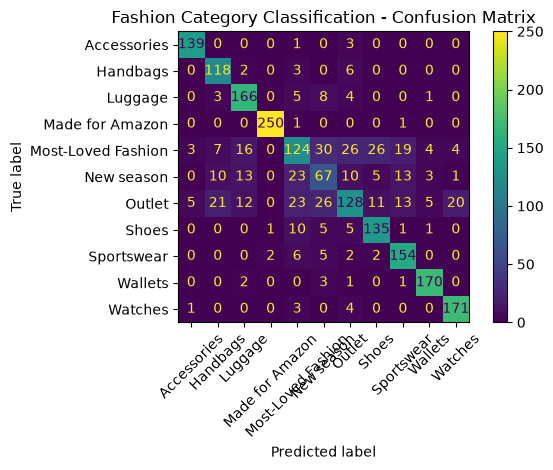

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Fashion Category Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

Trying New Products

In [76]:
new_products = pd.DataFrame({
    'title': [
        "Nike Men's Air Max Running Shoes",
        "Casio Men's Digital Sports Watch",
        "Leather Women's Shoulder Handbag",
        "Adidas Men's Training T-Shirt",
        "Leather RFID Men's Wallet"
    ],
    'brand': [
        "Nike",
        "Casio",
        "Generic",
        "adidas",
        "Generic"
    ],
    'price': [
        150,
        120,
        80,
        60,
        35
    ]
})

predictions = model.predict(new_products)

new_products['predicted_category'] = predictions

print(new_products)

                              title    brand  price predicted_category
0  Nike Men's Air Max Running Shoes     Nike    150              Shoes
1  Casio Men's Digital Sports Watch    Casio    120            Watches
2  Leather Women's Shoulder Handbag  Generic     80           Handbags
3     Adidas Men's Training T-Shirt   adidas     60         Sportswear
4         Leather RFID Men's Wallet  Generic     35            Wallets


Improvement: Confusion Matrix

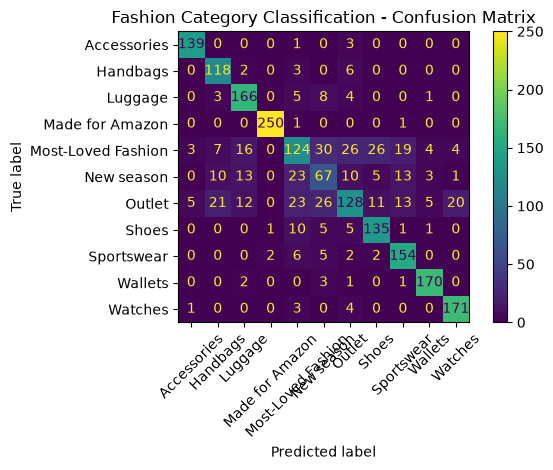

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Fashion Category Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

Better text features

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create an improved preprocessing pipeline
preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            'title',
            TfidfVectorizer(
                max_features=10000,
                ngram_range=(1, 3),
                stop_words='english',
                sublinear_tf=True
            ),
            'title'
        ),
        (
            'brand',
            OneHotEncoder(handle_unknown='ignore'),
            ['brand']
        ),
        (
            'price',
            StandardScaler(),
            ['price']
        )
    ]
)

# Create Version 2 of our model
model_v2 = Pipeline(
    steps=[
        ('preprocessor', preprocessor_v2),
        (
            'classifier',
            LogisticRegression(
                max_iter=1500,
                class_weight='balanced'
            )
        )
    ]
)

print("Improved model pipeline created successfully!")

Improved model pipeline created successfully!


In [79]:
print("Training improved Fashion Category Classifier...")

model_v2.fit(X_train, y_train)

print("Training completed!")

Training improved Fashion Category Classifier...
Training completed!


In [80]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_v2 = model_v2.predict(X_test)

# Calculate accuracy
accuracy_v2 = accuracy_score(y_test, y_pred_v2)

print(f"Baseline Accuracy: {accuracy:.2%}")
print(f"Version 2 Accuracy: {accuracy_v2:.2%}")

print("\nVersion 2 Classification Report:")
print(classification_report(y_test, y_pred_v2, zero_division=0))

Baseline Accuracy: 78.59%
Version 2 Accuracy: 78.68%

Version 2 Classification Report:
                    precision    recall  f1-score   support

       Accessories       0.93      0.97      0.95       143
          Handbags       0.75      0.91      0.82       129
           Luggage       0.80      0.90      0.85       187
   Made for Amazon       0.99      0.99      0.99       252
Most-Loved Fashion       0.62      0.47      0.54       259
        New season       0.47      0.44      0.46       145
            Outlet       0.69      0.48      0.57       264
             Shoes       0.74      0.87      0.80       158
        Sportswear       0.75      0.89      0.82       171
           Wallets       0.91      0.97      0.94       177
           Watches       0.87      0.98      0.92       179

          accuracy                           0.79      2064
         macro avg       0.77      0.81      0.79      2064
      weighted avg       0.78      0.79      0.78      2064



Version 3 — Linear SVM (changing the classifier)

In [81]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

model_v3 = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LinearSVC(
                class_weight='balanced',
                random_state=42
            )
        )
    ]
)

print("Version 3 model pipeline created successfully!")

Version 3 model pipeline created successfully!


In [82]:
print("Training Version 3 - Linear SVM...")

model_v3.fit(X_train, y_train)

print("Training completed!")

Training Version 3 - Linear SVM...
Training completed!


In [83]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_v3 = model_v3.predict(X_test)

# Calculate accuracy
accuracy_v3 = accuracy_score(y_test, y_pred_v3)

print(f"Baseline Accuracy: {accuracy:.2%}")
print(f"Version 2 Accuracy: {accuracy_v2:.2%}")
print(f"Version 3 Accuracy: {accuracy_v3:.2%}")

print("\nVersion 3 Classification Report:")
print(classification_report(y_test, y_pred_v3, zero_division=0))

Baseline Accuracy: 78.59%
Version 2 Accuracy: 78.68%
Version 3 Accuracy: 78.10%

Version 3 Classification Report:
                    precision    recall  f1-score   support

       Accessories       0.96      0.95      0.95       143
          Handbags       0.76      0.88      0.82       129
           Luggage       0.79      0.88      0.83       187
   Made for Amazon       0.99      1.00      0.99       252
Most-Loved Fashion       0.60      0.48      0.53       259
        New season       0.43      0.44      0.44       145
            Outlet       0.67      0.52      0.59       264
             Shoes       0.75      0.83      0.79       158
        Sportswear       0.76      0.85      0.80       171
           Wallets       0.93      0.96      0.94       177
           Watches       0.87      0.97      0.92       179

          accuracy                           0.78      2064
         macro avg       0.77      0.80      0.78      2064
      weighted avg       0.77      0.78     

In [84]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Create confusion matrix using our best model (Version 2)
cm = confusion_matrix(y_test, y_pred_v2, labels=model_v2.classes_)

# Convert it into a readable table
confusion_df = pd.DataFrame(
    cm,
    index=model_v2.classes_,
    columns=model_v2.classes_
)

print("Confusion Matrix:")
print(confusion_df)

Confusion Matrix:
                    Accessories  Handbags  Luggage  Made for Amazon  \
Accessories                 139         0        0                0   
Handbags                      0       118        1                0   
Luggage                       0         3      169                0   
Made for Amazon               0         0        0              249   
Most-Loved Fashion            3         8       15                0   
New season                    0        10       12                0   
Outlet                        7        19       12                0   
Shoes                         0         0        0                1   
Sportswear                    0         0        0                2   
Wallets                       0         0        2                0   
Watches                       1         0        0                0   

                    Most-Loved Fashion  New season  Outlet  Shoes  Sportswear  \
Accessories                          1          

In [85]:
# Find the biggest classification mistakes
errors = []

for actual in model_v2.classes_:
    for predicted in model_v2.classes_:
        if actual != predicted:
            count = confusion_df.loc[actual, predicted]

            if count > 0:
                errors.append({
                    'Actual Category': actual,
                    'Predicted Category': predicted,
                    'Number of Errors': count
                })

# Convert to DataFrame and sort
error_df = pd.DataFrame(errors)

error_df = error_df.sort_values(
    by='Number of Errors',
    ascending=False
)

print("Top 15 Classification Errors:")
print(error_df.head(15).to_string(index=False))

Top 15 Classification Errors:
   Actual Category Predicted Category  Number of Errors
Most-Loved Fashion         New season                29
Most-Loved Fashion              Shoes                27
            Outlet         New season                25
        New season Most-Loved Fashion                24
Most-Loved Fashion             Outlet                23
            Outlet Most-Loved Fashion                23
Most-Loved Fashion         Sportswear                21
            Outlet            Watches                20
            Outlet           Handbags                19
Most-Loved Fashion            Luggage                15
        New season         Sportswear                14
            Outlet              Shoes                13
            Outlet            Luggage                12
            Outlet         Sportswear                12
        New season            Luggage                12


Feature ablation - we remove features and see whether they actually help.

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd


# --------------------------------------------------
# Experiment A: Title only
# --------------------------------------------------

title_only_preprocessor = ColumnTransformer(
    transformers=[
        (
            'title',
            TfidfVectorizer(
                max_features=10000,
                ngram_range=(1, 3),
                stop_words='english',
                sublinear_tf=True
            ),
            'title'
        )
    ]
)

title_only_model = Pipeline(
    steps=[
        ('preprocessor', title_only_preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1500,
                class_weight='balanced'
            )
        )
    ]
)

title_only_model.fit(X_train, y_train)

title_only_pred = title_only_model.predict(X_test)

title_only_accuracy = accuracy_score(
    y_test,
    title_only_pred
)

title_only_f1 = f1_score(
    y_test,
    title_only_pred,
    average='macro'
)


# --------------------------------------------------
# Experiment B: Title + Brand
# --------------------------------------------------

title_brand_preprocessor = ColumnTransformer(
    transformers=[
        (
            'title',
            TfidfVectorizer(
                max_features=10000,
                ngram_range=(1, 3),
                stop_words='english',
                sublinear_tf=True
            ),
            'title'
        ),
        (
            'brand',
            OneHotEncoder(handle_unknown='ignore'),
            ['brand']
        )
    ]
)

title_brand_model = Pipeline(
    steps=[
        ('preprocessor', title_brand_preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1500,
                class_weight='balanced'
            )
        )
    ]
)

title_brand_model.fit(X_train, y_train)

title_brand_pred = title_brand_model.predict(X_test)

title_brand_accuracy = accuracy_score(
    y_test,
    title_brand_pred
)

title_brand_f1 = f1_score(
    y_test,
    title_brand_pred,
    average='macro'
)


# --------------------------------------------------
# Experiment C: Title + Brand + Price
# --------------------------------------------------

title_brand_price_preprocessor = ColumnTransformer(
    transformers=[
        (
            'title',
            TfidfVectorizer(
                max_features=10000,
                ngram_range=(1, 3),
                stop_words='english',
                sublinear_tf=True
            ),
            'title'
        ),
        (
            'brand',
            OneHotEncoder(handle_unknown='ignore'),
            ['brand']
        ),
        (
            'price',
            StandardScaler(),
            ['price']
        )
    ]
)

title_brand_price_model = Pipeline(
    steps=[
        ('preprocessor', title_brand_price_preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1500,
                class_weight='balanced'
            )
        )
    ]
)

title_brand_price_model.fit(X_train, y_train)

title_brand_price_pred = title_brand_price_model.predict(X_test)

title_brand_price_accuracy = accuracy_score(
    y_test,
    title_brand_price_pred
)

title_brand_price_f1 = f1_score(
    y_test,
    title_brand_price_pred,
    average='macro'
)


# --------------------------------------------------
# Compare all experiments
# --------------------------------------------------

comparison = pd.DataFrame({
    'Experiment': [
        'Title only',
        'Title + Brand',
        'Title + Brand + Price'
    ],
    'Accuracy': [
        title_only_accuracy,
        title_brand_accuracy,
        title_brand_price_accuracy
    ],
    'Macro F1': [
        title_only_f1,
        title_brand_f1,
        title_brand_price_f1
    ]
})

comparison['Accuracy'] = comparison['Accuracy'].round(4)
comparison['Macro F1'] = comparison['Macro F1'].round(4)

print("\nFeature Ablation Results:")
print(comparison.to_string(index=False))


Feature Ablation Results:
           Experiment  Accuracy  Macro F1
           Title only    0.7481    0.7457
        Title + Brand    0.7859    0.7851
Title + Brand + Price    0.7868    0.7856


Tuning - cross-validation on the training data

In [87]:
from sklearn.model_selection import GridSearchCV

# Create the parameter values we want to test
param_grid = {
    'classifier__C': [0.1, 0.5, 1, 2, 5]
}

# Use our Version 2 model as the model to tune
grid_search = GridSearchCV(
    estimator=model_v2,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning...")

grid_search.fit(X_train, y_train)

print("\nTuning completed!")

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(f"{grid_search.best_score_:.4f}")

Starting hyperparameter tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Tuning completed!

Best parameters:
{'classifier__C': 2}

Best cross-validation Macro F1:
0.7831


Final model

In [88]:
# Get the best model found by GridSearchCV
final_model = grid_search.best_estimator_

print("Final model selected successfully!")

print("\nBest parameters:")
print(grid_search.best_params_)

Final model selected successfully!

Best parameters:
{'classifier__C': 2}


In [89]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the untouched test set
final_predictions = final_model.predict(X_test)

# Calculate final accuracy
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

# Calculate final Macro F1
final_macro_f1 = f1_score(
    y_test,
    final_predictions,
    average='macro'
)

print("===================================")
print("       FINAL MODEL PERFORMANCE")
print("===================================")

print(f"Accuracy : {final_accuracy:.4f} ({final_accuracy:.2%})")
print(f"Macro F1 : {final_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)

       FINAL MODEL PERFORMANCE
Accuracy : 0.7883 (78.83%)
Macro F1 : 0.7882

Classification Report:
                    precision    recall  f1-score   support

       Accessories       0.93      0.99      0.96       143
          Handbags       0.76      0.90      0.83       129
           Luggage       0.80      0.90      0.84       187
   Made for Amazon       0.99      0.99      0.99       252
Most-Loved Fashion       0.61      0.49      0.54       259
        New season       0.46      0.44      0.45       145
            Outlet       0.70      0.50      0.59       264
             Shoes       0.75      0.84      0.79       158
        Sportswear       0.76      0.87      0.81       171
           Wallets       0.92      0.97      0.95       177
           Watches       0.88      0.98      0.92       179

          accuracy                           0.79      2064
         macro avg       0.78      0.81      0.79      2064
      weighted avg       0.78      0.79      0.78      206

In [92]:
import joblib

# Save the final trained model
joblib.dump(final_model, "fashion_category_classifier.pkl")



['fashion_category_classifier.pkl']